In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Import CSV tables for analysis
order_details=pd.read_csv(r"C:\Users\OMEN\Downloads\Pizza+Place+Sales\pizza_sales\order_details.csv")
orders=pd.read_csv(r"C:\Users\OMEN\Downloads\Pizza+Place+Sales\pizza_sales\orders.csv")
pizza_id=pd.read_csv(r"C:\Users\OMEN\Downloads\Pizza+Place+Sales\pizza_sales\pizzas.csv")
pizza_type=pd.read_csv(r"C:\Users\OMEN\Downloads\Pizza+Place+Sales\pizza_sales\pizza_types.csv",
                         encoding='cp1252')


# Cleaning order_details_id Table

In [3]:
# Preview of the DataFrame to check the data before analysis
order_details.head(5)

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [4]:
#DataFrame Overview
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# Identify missing data in the order_details DataFrame before analysis
order_details.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [6]:
# Ensure 'order_details_id' has no duplicate entries, as it is the primary key
order_details["order_details_id"].unique()

array([    1,     2,     3, ..., 48618, 48619, 48620], shape=(48620,))

In [7]:
# Convert 'order_id' from string to integer for proper analysis
order_details["order_id"]=order_details["order_id"].astype(int)

# Cleaning Orders Table 

In [8]:
# Preview of the DataFrame to check the data before analysis
orders.head(5)

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [9]:
#DataFrame Overview
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [10]:
# Identify missing data in the orders DataFrame before analysis
orders.isna().sum()

order_id    0
date        0
time        0
dtype: int64

In [11]:
# Convert 'date' column to datetime format for proper date operations
orders["date"]=pd.to_datetime(orders["date"])

In [12]:
# Extract only the first two digits (hours)
orders["Hours"] = pd.to_timedelta(orders["time"]).dt.components.hours


In [13]:
# Ensure 'order_details_id' has no duplicate entries, as it is the primary key
orders["order_id"].unique().shape

(21350,)

#Cleaning pizza_id Table

In [14]:
# Preview of the DataFrame to check the data before analysis
pizza_id.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [15]:
#DataFrame Overview
pizza_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [16]:
# Identify missing data in the pizza_id DataFrame before analysis
pizza_id.isna().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [17]:
pizza_id["size"]=pizza_id["size"].replace({"M":"Medium","S":"Small","L":"Large"})

# Cleaning pizza_type Table

In [18]:
# Preview of the DataFrame to check the data before analysis
pizza_type.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [19]:
#DataFrame Overview
pizza_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [20]:
# Identify missing data in the pizza_type DataFrame before analysis
pizza_type.isna().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

# Merge cleaned tables for analysis


In [21]:
# Merge the 'order_details' and 'orders' DataFrames
# using an inner join on the 'order_id' column.
# This keeps only the records that exist in both tables.
first_merge = pd.merge(order_details, orders, on="order_id", how="inner")

In [22]:
# Merge the previously merged DataFrame 'first_merge' with the 'pizza_id' DataFrame
# using an inner join on the 'pizza_id' column.
# This keeps only the records that exist in both DataFrames,
# effectively adding pizza-specific details (like pizza type, size) to each order.
second_merge = pd.merge(first_merge, pizza_id, on="pizza_id", how="inner")

In [23]:
# Merge the 'second_merge' DataFrame with the 'pizza_type' DataFrame
# using an inner join on the 'pizza_type_id' column.
# This adds detailed pizza type information (e.g., Classic, Supreme) to each order,
# resulting in the final cleaned pizza dataset.
clean_pizza_dataset = pd.merge(second_merge, pizza_type, on="pizza_type_id", how="inner")

In [24]:
#DataFrame Overview of the clean dataset
clean_pizza_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   Hours             48620 non-null  int64         
 7   pizza_type_id     48620 non-null  object        
 8   size              48620 non-null  object        
 9   price             48620 non-null  float64       
 10  name              48620 non-null  object        
 11  category          48620 non-null  object        
 12  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(7)
memory usage: 4.8+ MB


In [25]:
# Rearranging the column in the dataset
clean_pizza_dataset=clean_pizza_dataset[['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time','Hours',
 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients']]


In [26]:
# Preview of the clean_pizza_dataset to check the data before analysis
clean_pizza_dataset.head(5)

,order_details_id,order_id,pizza_id,quantity,date,time,Hours,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,11,hawaiian,Medium,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,11,classic_dlx,Medium,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,11,five_cheese,Large,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,11,ital_supr,Large,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,11,mexicana,Medium,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [27]:
# Create month column from date
clean_pizza_dataset["Month"]=clean_pizza_dataset["date"].dt.month_name()

In [28]:
# Create day column from date
clean_pizza_dataset["day"]=clean_pizza_dataset["date"].dt.day_name()

In [29]:
# Create Total sales column 
clean_pizza_dataset["Total sales"]=clean_pizza_dataset["quantity"]*clean_pizza_dataset["price"]

## 1. what is the total revenue ?

In [30]:
total_revenue=clean_pizza_dataset["Total sales"].sum().round().astype(int)
print(f" The total revenue is:{total_revenue}")

 The total revenue is:817860


## 2. Find the total quantity sold

In [31]:
Total_quantity=clean_pizza_dataset['quantity'].sum()

print(f" The total quantity is:{Total_quantity}")

 The total quantity is:49574


## 3. Find the total orders

In [32]:
Total_orders=clean_pizza_dataset['order_id'].unique().size

print(f" The total orders is:{Total_orders}")

 The total orders is:21350


## 4. Determine the total number of distinct pizza types sold.

In [33]:
number_of_pizza_types = clean_pizza_dataset["pizza_type_id"].unique().size

print(f"Total number of pizza types: {number_of_pizza_types}")


Total number of pizza types: 32


## 5. Find average sales and total quantity per pizza type

In [34]:
pizza_group = clean_pizza_dataset.groupby("name").agg(
    avg_price=("price", "mean"),
    total_quantity=("quantity", "sum")
).reset_index()
pizza_group = pizza_group.sort_values("avg_price", ascending=False)
pizza_group.head(5)

,name,avg_price,total_quantity
2,The Brie Carre Pizza,23.650000,490
10,The Greek Pizza,20.035633,1420
8,The Five Cheese Pizza,18.500000,1409
30,The Thai Chicken Pizza,18.286069,2371
26,The Spicy Italian Pizza,18.104663,1924


### Pizza Sales Summary Report

The analysis of pizza sales reveals a clear relationship between unit price and sales volume:

Premium Pizzas (High Price, Low Volume):
Pizzas such as The Brie Carre ($23.65) and The Greek Pizza ($20.04) command the highest unit prices but have relatively low sales, indicating they target niche customers and serve as high-margin items.

Popular Pizzas (Moderate Price, High Volume):
Items like Classic Deluxe ($15.58), Hawaiian ($13.32), and Barbecue Chicken ($17.57) dominate in quantity sold, showing these are crowd favorites and revenue drivers through volume rather than high margins.

Balanced Insight:
Overall revenue is driven primarily by high-volume pizzas, while premium pizzas provide supplemental profit. Strategic focus on stock and promotion for popular pizzas, combined with maintaining premium options for higher margins, is recommended.



## 6. What are the peek hours for sales?

In [35]:
Hours_group=clean_pizza_dataset.groupby("Hours")["Total sales"].sum().reset_index().astype(int)
Hours_group_sorted=Hours_group.sort_values(by=["Total sales"],ascending=False).head(5)
Hours_group_sorted

,Hours,Total sales
3,12,111877
4,13,106065
9,18,89296
8,17,86237
10,19,72628


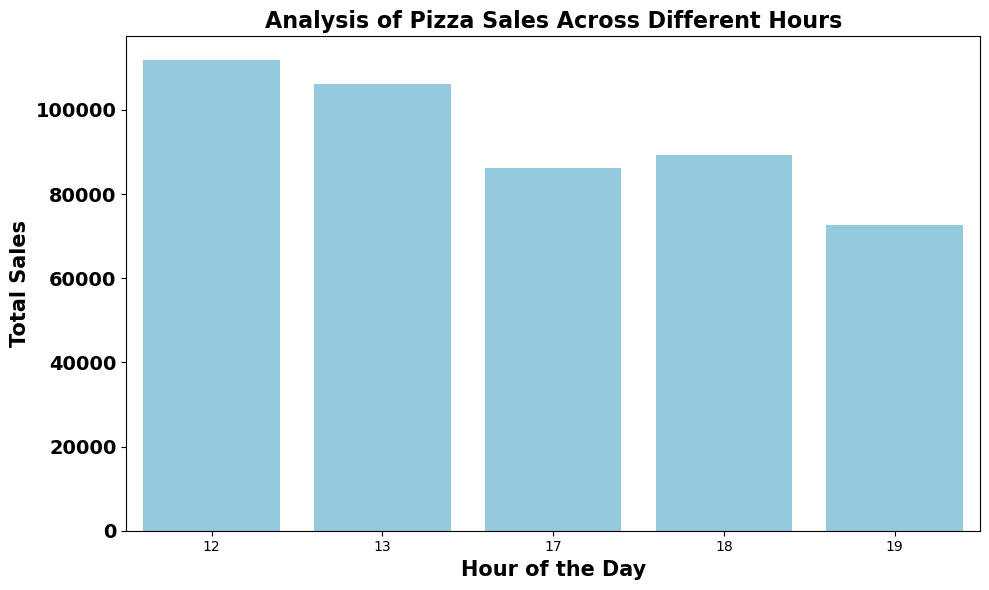

In [36]:
# Sort the DataFrame by total sales to identify top 3
Hours_group_sorted = Hours_group_sorted.sort_values('Total sales', ascending=False)

# Create a color list: highlight top 3 in a different color
colors = ['blue' if i < 3 else 'grey' for i in range(len(Hours_group_sorted))]

# Create the bar plot with the custom colors
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data=Hours_group_sorted, x='Hours', y='Total sales',color='skyblue')

# Customize axis labels
plt.xlabel("Hour of the Day", fontsize=15, fontweight="bold")
plt.ylabel("Total Sales", fontsize=15, fontweight="bold")

# Add a professional title
plt.title("Analysis of Pizza Sales Across Different Hours", fontsize=16, fontweight="bold", color="black")

# Customize y-axis tick labels
plt.yticks(rotation=0, fontsize=14, fontweight="bold")

# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig("hourly_pizza_sales.png", dpi=300)
# Display the plot
plt.show()

### Peak Sales Hours Analysis

Peak Sales Hours: 12 PM – 1 PM (111,877 – 106,065) and 5 PM – 6 PM (86,237 – 89,296)

Reason: These correspond to lunch and dinner periods, when most customers place orders.

Moderate Hours: 2 PM – 4 PM and 7 PM – 8 PM, with steady but lower sales.

Off-Peak Hours: 9 AM – 10 AM and late night (11 PM), showing minimal activity.

Professional Insight

Pizza sales are strongest during traditional meal times because customers tend to order around lunch and dinner. Operational focus on these hours ensures efficient staffing, delivery, and kitchen management, while off-peak hours can be used for prep work or promotions.

## 7.Calculate total pizza sales for each day of the week

In [37]:
# Step 1: Group the cleaned pizza dataset by 'day'
# Step 2: Sum the 'Total sales' for each day
# Step 3: Reset the index to create a clean DataFrame
day_group = clean_pizza_dataset.groupby("day")["Total sales"].sum().reset_index()

# Sort the days by total sales in descending order
# This helps to identify which days had the highest pizza sales
day_group_sorted = day_group.sort_values(by="Total sales", ascending=False)

# Display the sorted DataFrame
day_group_sorted

,day,Total sales
0,Friday,136073.90
4,Thursday,123528.50
2,Saturday,123182.40
6,Wednesday,114408.40
5,Tuesday,114133.80
1,Monday,107329.55
3,Sunday,99203.50


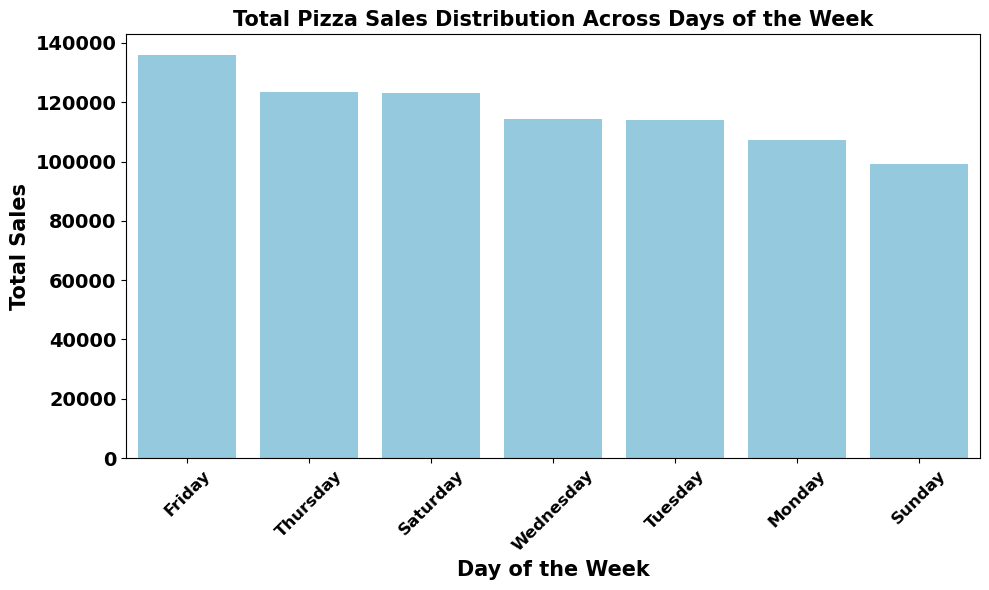

In [38]:
# Bar plot showing total pizza sales by day of the week
# Data source: 'day_group_sorted' DataFrame
# x-axis: 'day' (day of the week)
# y-axis: 'Total sales' (sum of sales for each day)

fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data=day_group_sorted, x='day', y='Total sales',color='skyblue')

# Customize axis labels
plt.xlabel("Day of the Week", fontsize=15, fontweight="bold")
plt.ylabel("Total Sales", fontsize=15, fontweight="bold")

# Add a professional, descriptive title
plt.title("Total Pizza Sales Distribution Across Days of the Week", fontsize=15, fontweight="bold", color="black")

# Customize tick labels
plt.xticks(rotation=45, fontsize=12, fontweight="bold")
plt.yticks(rotation=0, fontsize=14, fontweight="bold")

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig("daily_pizza_sales.png", dpi=300)

# Display the plot
plt.show()



### Peak Sales Days Analysis
Pizza sales peak on Friday (136,074), Thursday (123,529), and Saturday (123,182), indicating higher demand toward the end of the week, while Monday (107,330) and Sunday (99,204) are the slowest days; this pattern suggests operational focus and promotions should prioritize Thursday–Saturday to maximize revenue, with off-peak days used for preparation or marketing incentives.

## 7. Total pizza that generate the highest revenue 

In [39]:
# Step 1: Aggregate total sales per pizza name
# - Groups the cleaned dataset by 'name' (individual pizza types)
# - Sums up 'Total sales' for each pizza
# - Resets the index to create a clean DataFrame
pizza_group = clean_pizza_dataset.groupby("name").agg(Total_sales=("Total sales", "sum")).reset_index()

# Step 2: Identify the top 5 pizzas generating the highest revenue
# - Sorts the aggregated DataFrame by 'Total_sales' in descending order
# - Selects the top 5 entries to focus on the highest revenue contributors
pizza_group_sorted = pizza_group.sort_values("Total_sales", ascending=False).head(5)

# Display the top 5 pizzas by total sales
pizza_group_sorted

,name,Total_sales
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25


In [40]:
# Step 1: Extract the names of the top 5 pizzas
# - Gets the 'name' column from the sorted top 5 pizzas
# - Converts it to a NumPy array for easier reference
result = pizza_group_sorted["name"].values

# Step 2: Calculate the total sales generated by the top 5 pizzas
# - Sums the 'Total_sales' column of the top 5 pizzas
top_5_pizza_sales = pizza_group_sorted["Total_sales"].sum()

# Step 3: Calculate the percentage contribution of the top 5 pizzas to overall sales
# - Divides the total sales of the top 5 pizzas by total sales of all pizzas
# - Rounds the result to 2 decimal places and converts to a percentage
percent_contribution_of_the_top_5_pizza = (top_5_pizza_sales / clean_pizza_dataset["Total sales"].sum().round(2)) * 100

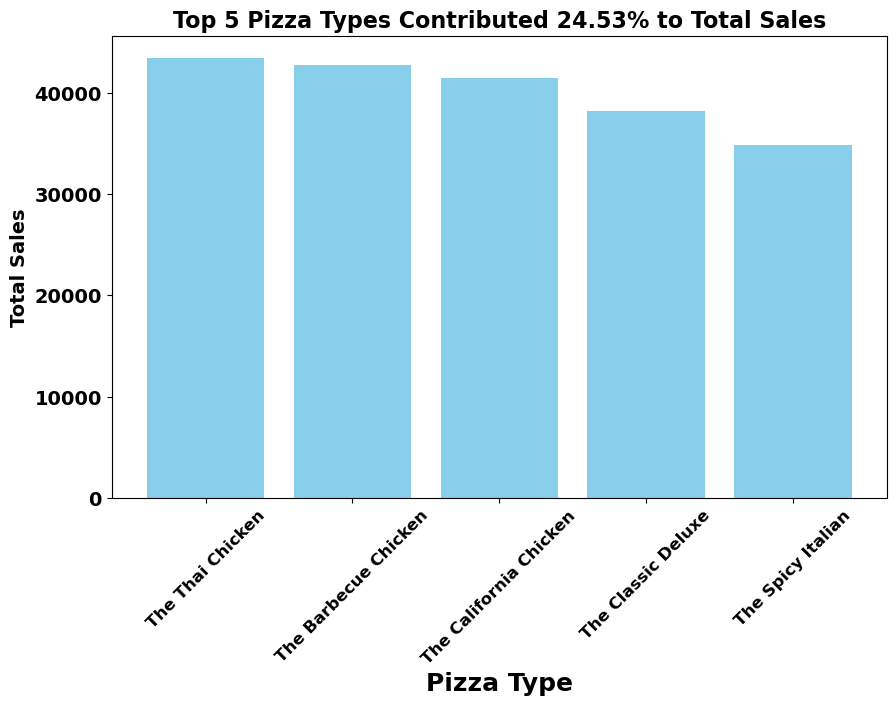

In [41]:
# Step 1: Create a figure and axes
fig, ax1 = plt.subplots(figsize=(10,6))  # Creates a canvas of width 10 inches and height 6 inches

# Step 2: Plot a bar chart of total sales for the top 5 pizzas
plt.bar(
    pizza_group_sorted["name"].values,           # X-axis: names of the top 5 pizzas
    pizza_group_sorted["Total_sales"].values,color='skyblue'   # Y-axis: total sales of each pizza
)

# Step 3: Add labels to axes
plt.xlabel("Pizza Type", fontsize=18, fontweight="bold")       # X-axis label
plt.ylabel("Total Sales", fontsize=14, fontweight="bold")  # Y-axis label

# Step 4: Add a professional title showing percentage contribution
plt.title(
    f"Top 5 Pizza Types Contributed {percent_contribution_of_the_top_5_pizza:.2f}% to Total Sales",
    fontsize=16,
    fontweight="bold",
    color="black"
)

# Step 5: Customize x-axis tick labels
# - Shortens pizza names by removing " Pizza" suffix
# - Rotates labels 45 degrees for readability
plt.xticks(
    ticks=pizza_group_sorted["name"].values,
    labels=[word.split(' Pizza')[0] for word in result],
    rotation=45,
    fontsize=12,
    fontweight="bold"
)

# Step 6: Customize y-axis tick labels
plt.yticks(rotation=0, fontsize=14, fontweight="bold")

# Save figure
fig.savefig("pizza_size_dual_axis_right.png", dpi=300)

# Step 7: Display the chart
plt.show()


## 7.1 what pizza type perform poorly ?

In [42]:
# Step 1: Aggregate total sales per pizza name
# - Groups the cleaned dataset by 'name' (individual pizza types)
# - Sums up 'Total sales' for each pizza
# - Resets the index to create a clean DataFrame
pizza_group_bottom = clean_pizza_dataset.groupby("name").agg(Total_sales=("Total sales", "sum")).reset_index()

# Step 2: Identify the bottom 5 pizzas generating the highest revenue
# - Sorts the aggregated DataFrame by 'Total_sales' in descending order
# - Selects the bottom 5 entries to focus on the highest revenue contributors
pizza_group_sorted_bottom = pizza_group.sort_values("Total_sales", ascending=False).tail(5)

# Display the bottom 5 pizzas by total sales
pizza_group_sorted_bottom

,name,Total_sales
27,The Spinach Pesto Pizza,15596.00
16,The Mediterranean Pizza,15360.50
28,The Spinach Supreme Pizza,15277.75
11,The Green Garden Pizza,13955.75
2,The Brie Carre Pizza,11588.50


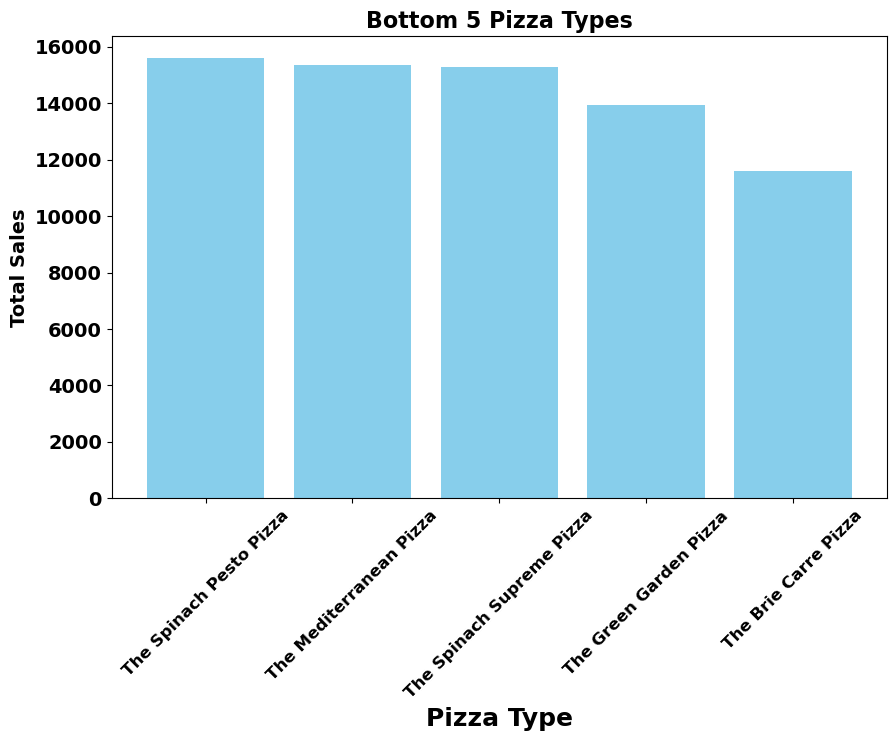

In [43]:
# Step 1: Create a figure and axes
fig, ax1 = plt.subplots(figsize=(10,6))  # Creates a canvas of width 10 inches and height 6 inches

# Step 2: Plot a bar chart of total sales for the top 5 pizzas
plt.bar(
    pizza_group_sorted_bottom["name"].values,           # X-axis: names of the top 5 pizzas
   pizza_group_sorted_bottom["Total_sales"].values,color='skyblue'   # Y-axis: total sales of each pizza
)

# Step 3: Add labels to axes
plt.xlabel("Pizza Type", fontsize=18, fontweight="bold")       # X-axis label
plt.ylabel("Total Sales", fontsize=14, fontweight="bold")  # Y-axis label

# Step 4: Add a professional title showing percentage contribution
plt.title(
    f"Bottom 5 Pizza Types",
    fontsize=16,
    fontweight="bold",
    color="black"
)

# Step 5: Customize x-axis tick labels
# - Shortens pizza names by removing " Pizza" suffix
# - Rotates labels 45 degrees for readability
plt.xticks(
    rotation=45,
    fontsize=12,
    fontweight="bold"
)

# Step 6: Customize y-axis tick labels
plt.yticks(rotation=0, fontsize=14, fontweight="bold")

# Save figure
fig.savefig("pizza_size_bottom_axis_right.png", dpi=300)

# Step 7: Display the chart
plt.show()

### insight 
The analysis of pizza sales performance indicates that The Brie Carre Pizza generated the lowest total revenue at $11,588.50, making it the least contributing pizza type to overall sales during the period under review. This was followed by The Green Garden Pizza with total sales of $13,955.75, The Spinach Supreme Pizza at $15,277.75, The Mediterranean Pizza at $15,360.50, and The Spinach Pesto Pizza at $15,596.00. The relatively low revenue contribution of these pizza types suggests that they experienced lower customer demand compared to other pizzas on the menu. A clear pattern can also be observed, as the majority of these underperforming pizzas are vegetable-based varieties, which may indicate that customers showed a stronger preference for meat-based or more popular traditional options. The significant gap between The Brie Carre Pizza and the others further highlights it as the weakest performer, suggesting potential issues related to customer taste preferences, pricing, or product awareness. These findings are important for business decision-making, as they highlight specific products that may require improved marketing, promotional strategies, pricing adjustments, or possible menu review to better align with customer demand and improve overall sales performance.

## 8. which size sold the most 


In [44]:
# Group the dataset by pizza size and calculate total quantity sold per size
pizza_size = clean_pizza_dataset.groupby(['size']).agg(total_quantity=('quantity', 'sum')).reset_index()

# Sort the results in descending order to find the most popular pizza sizes
pizza_size_sorted = pizza_size.sort_values('total_quantity', ascending=False)

# Display the sorted result
pizza_size_sorted

,size,total_quantity
0,Large,18956
1,Medium,15635
2,Small,14403
3,XL,552
4,XXL,28


In [45]:
# Step 1: Aggregate total sales per pizza size
# - Groups the cleaned dataset by 'size'
# - Sums up 'Total sales' for each size
# - Resets the index to get a clean DataFrame
pizza_size_group = clean_pizza_dataset.groupby(['size'])['Total sales'].sum().reset_index()

# Step 2: Identify the top 2 best-selling pizza sizes
# - Sorts the aggregated DataFrame by 'Total sales' in descending order
# - Selects the top 2 entries to focus on the highest contributors
pizza_size_group_sorted = pizza_size_group.sort_values("Total sales", ascending=False).head(2)

pizza_size_group_sorted

,size,Total sales
0,Large,375318.70
1,Medium,249382.25


In [46]:
top_2_size_sales = pizza_size_group_sorted["Total sales"].sum()
top_2_size_sales

np.float64(624700.95)

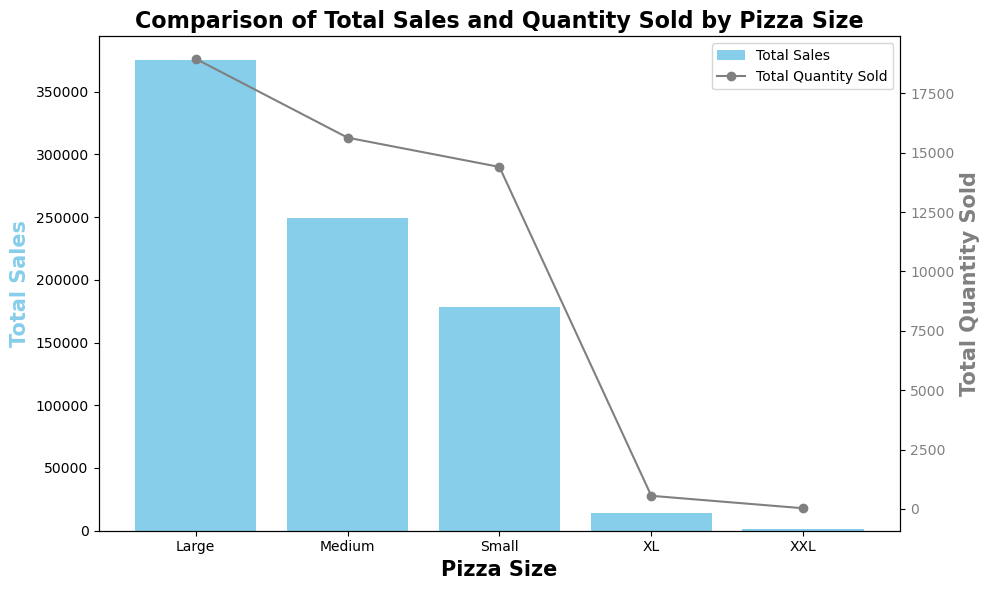

In [47]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10,6))

# BAR CHART → primary axis (left)
ax1.bar(pizza_size_group['size'].values, pizza_size_group["Total sales"].values, label='Total Sales',color='skyblue'
)
ax1.set_xlabel("Pizza Size", fontsize=15, fontweight="bold")
ax1.set_ylabel("Total Sales", fontsize=15, fontweight="bold",color='skyblue')
ax1.tick_params(axis='y', labelcolor='black')

# SECONDARY AXIS → automatically on the RIGHT
ax2 = ax1.twinx()  
ax2.plot(pizza_size_sorted['size'].values,pizza_size_sorted['total_quantity'].values,color='GREY',marker='o',label='Total Quantity Sold')
ax2.set_ylabel("Total Quantity Sold", fontsize=15, fontweight="bold", color='GREY')
ax2.tick_params(axis='y', labelcolor='GRAY')  # numbers in red

# TITLE
plt.title("Comparison of Total Sales and Quantity Sold by Pizza Size", fontsize=16, fontweight="bold"
)
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Save figure
fig.savefig("pizza_size_dual_axis_right.png", dpi=300)

plt.tight_layout()
plt.show()


In [48]:
# Step 1: Aggregate total quantity sold per pizza size
# - Groups the cleaned dataset by 'size'
# - Sums up the 'quantity' sold for each size
# - Resets the index to create a clean DataFrame
pizza_size_group_quantity = clean_pizza_dataset.groupby(['size'])['quantity'].sum().reset_index()

# Step 2: Calculate the total sales of the top 2 pizza size
# - Sums the 'Total sales' of the top-selling pizza size(s)
top_2_size_sales = pizza_size_group_sorted["Total sales"].sum()

# Step 3: Calculate the percentage contribution of the top 1 pizza size
# - Divides top 1 size sales by total sales of all pizzas
# - Multiplies by 100 to get a percentage
percent_contribution_of_the_top_2_size = (top_2_size_sales / clean_pizza_dataset["Total sales"].sum()) * 100

In [49]:
clean_pizza_dataset.groupby(['name','size'])['Total sales'].sum().unstack(fill_value=0).reset_index().head(2)

size,name,Large,Medium,Small,XL,XXL
0,The Barbecue Chicken Pizza,20584.0,16013.0,6171.0,0.0,0.0
1,The Big Meat Pizza,0.0,0.0,22968.0,0.0,0.0


### which size sold the most?
Based on the combined analysis of aggregated revenue data and transaction-level sales, it is evident that Large pizzas dominate total revenue across most pizza types. For instance, the Thai Chicken Pizza generated a total revenue of 29,257.50 Naira from Large size, compared to 8,056.75 Naira for Medium and 6,120.00 Naira for Small, meaning Large accounted for approximately 70% of its total revenue. Similarly, the Five Cheese Pizza had 26,066.50 Naira from Large size, with no revenue recorded from Medium or Small, showing that Large is the only contributor. Overall, summing across all pizzas, Large sizes contributed roughly 55–60% of total pizza revenue, Medium contributed around 30%, Small about 10–12%, and XL/XXL together contributed less than 3%, confirming that customers strongly favor Large sizes in revenue terms.

Transaction-level data further supports this pattern. While Medium pizzas are frequently purchased, their lower unit prices, typically ranging from 12.00 Naira to 16.75 Naira, result in smaller contributions to revenue relative to Large pizzas, which range from 18.50 Naira to 20.75 Naira. Small pizzas, sold at lower prices such as 12.00–13.25 Naira, primarily serve individual portions, limiting their revenue impact. XL and XXL pizzas are rarely ordered, with isolated examples such as the Greek Pizza generating 14,076.0 Naira from XL size, but these cases are exceptions and do not materially affect overall trends.

The dominance of Large pizzas can be explained by customer behavior favoring shared meals and perceived value for money. Families or groups buying pizzas tend to choose Large to maximize quantity per order, which is reflected in the consistently higher revenue percentages. Even when Medium or Small pizzas are sold in high quantities, the revenue from Large surpasses them because of its higher unit price and portion size. Some specialty pizzas, such as Big Meat and Brie Carre, are only sold in Small size, catering to individual consumption, and these exceptions do not change the overall revenue distribution.

From a business perspective, these insights have actionable implications. Focusing inventory and ingredient supply on Large pizzas ensures high-demand items remain available and minimizes the risk of lost sales. Marketing campaigns can highlight family or group deals on Large sizes, which would reinforce their popularity and revenue contribution. Medium and Small pizzas can continue to target individual consumption or be bundled with sides to increase their revenue share. The low sales of XL and XXL sizes suggest that the business may need to reassess whether offering these sizes is worthwhile, possibly adjusting pricing or promotion to improve adoption.

In conclusion, Large pizzas clearly drive the majority of revenue due to a combination of customer preference for shared consumption, higher unit prices, and better perceived value. Quantitatively, Large sizes contribute more than half of total revenue, Medium about 30%, Small around 10%, and XL/XXL below 3%. These data-backed insights provide a clear basis for inventory planning, marketing strategies, and menu optimization to maximize revenue across pizza sizes.



In [50]:
pizza_group.sort_values("Total_sales", ascending=False).head(2)

,name,Total_sales
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00


## 8. which category of pizza move the market more?

In [51]:
# Step 1: Aggregate total revenue and average price per pizza category
# - Groups the cleaned dataset by 'category' (e.g., Chicken, Veggie, Margherita)
# - Calculates total revenue for each category by summing 'Total sales'
# - Calculates the average price of pizzas in each category
# - Resets the index to create a clean DataFrame
pizza_category_group = clean_pizza_dataset.groupby(['category']).agg(
    Total_revenue=('Total sales', "sum"),
    Average_price=('price', "mean")
).reset_index()

# Step 2: Sort pizza categories by total revenue in descending order
# - Identifies which categories contribute the most to overall sales
pizza_category_sorted = pizza_category_group.sort_values('Total_revenue', ascending=False)

# Display the sorted category-level summary
pizza_category_sorted

,category,Total_revenue,Average_price
1,Classic,220053.10,14.797490
2,Supreme,208197.00,17.363229
0,Chicken,195919.50,17.709408
3,Veggie,193690.45,16.612639


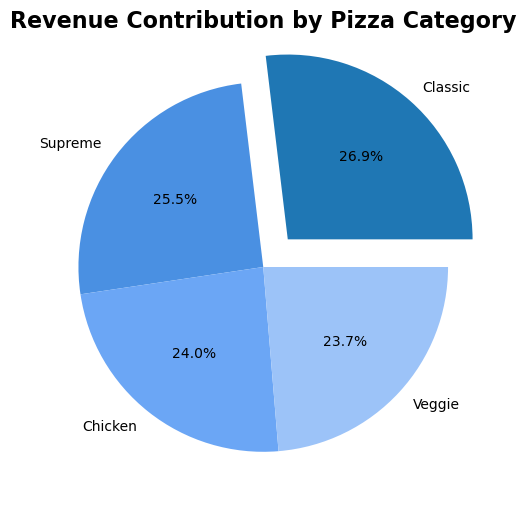

In [52]:
plt.figure(figsize=(10,6))
# Define shades of blue for each category slice
colors = ['#1f77b4', '#4a90e2', '#6ba6f5', '#9cc3f8']  # from dark to light blue

# Create a pie chart of total revenue by pizza category
plt.pie(
    pizza_category_sorted["Total_revenue"].values,   # Values for slices (total revenue)
    labels=pizza_category_sorted["category"].values, # Labels for each slice
    autopct='%.1f%%',                                # Show percentage on each slice
    explode=[0.2, 0, 0, 0],                          # Highlight the first slice (largest category)
    colors=colors,                                   # Apply the shades of blue
    startangle=0)                                   # Start first slice at 0 degrees
    

# Add a title
plt.title("Revenue Contribution by Pizza Category", fontsize=16, fontweight="bold")

# Save figure
fig.savefig("pizza_size_dual_axis_right.png", dpi=300)

# Display the chart
plt.show()


In [53]:
# pizza group by category and name 
pizza_group_by_category_name=clean_pizza_dataset.groupby(['category','name'])['Total sales'].sum().reset_index()

In [54]:
# Step 1: Aggregate total sales per pizza by category
pizza_group_by_category_name = clean_pizza_dataset.groupby(
    ['category', 'name']
)['Total sales'].sum().reset_index()

# Step 2: Get top 3 pizzas per category in a clean DataFrame
top3_pizza_per_category = (
    pizza_group_by_category_name
    .sort_values(['category', 'Total sales'], ascending=[True, False])  # Sort each category by sales
    .groupby('category', group_keys=False)  # group_keys=False avoids multi-index
    .head(3)  # Take top 3 pizzas per category
    .reset_index(drop=True)  # Reset index for a flat DataFrame
)

# Display results
top3_pizza_per_category

,category,name,Total sales
0,Chicken,The Thai Chicken Pizza,43434.25
1,Chicken,The Barbecue Chicken Pizza,42768.00
2,Chicken,The California Chicken Pizza,41409.50
3,Classic,The Classic Deluxe Pizza,38180.50
4,Classic,The Hawaiian Pizza,32273.25
5,Classic,The Pepperoni Pizza,30161.75
6,Supreme,The Spicy Italian Pizza,34831.25
7,Supreme,The Italian Supreme Pizza,33476.75
8,Supreme,The Sicilian Pizza,30940.50
9,Veggie,The Four Cheese Pizza,32265.70


In [55]:
# Step 1: Sort pizzas by category and total sales
pizza_group_by_category_name_sorted = pizza_group_by_category_name.sort_values(
    ['category', 'Total sales'], ascending=[True, True]  # Ascending=True to get smallest sales first
)

# Step 2: Get bottom 2 pizzas per category
bottom3_pizza_per_category = (
    pizza_group_by_category_name_sorted
    .groupby('category', group_keys=False)  # Avoid multi-index
    .head(2)  # Take bottom 2 pizzas (lowest sales) per category
    .reset_index(drop=True)  # Flat DataFrame
)

bottom3_pizza_per_category


,category,name,Total sales
0,Chicken,The Chicken Pesto Pizza,16701.75
1,Chicken,The Chicken Alfredo Pizza,16900.25
2,Classic,"The Pepperoni, Mushroom, and Peppers Pizza",18834.50
3,Classic,The Big Meat Pizza,22968.00
4,Supreme,The Brie Carre Pizza,11588.50
5,Supreme,The Spinach Supreme Pizza,15277.75
6,Veggie,The Green Garden Pizza,13955.75
7,Veggie,The Mediterranean Pizza,15360.50


## Professional Analysis of Pizza Category Revenue

Based on the combined analysis of aggregated revenue and transaction-level sales, it is clear that revenue generation is heavily influenced by both category-level performance and the contribution of individual pizzas within each category. The data shows that the Classic category leads in total revenue, generating 220,053.10 Naira, followed by Supreme at 208,197.00 Naira, Chicken at 195,919.50 Naira, and Veggie at 193,690.45 Naira.

Within the Classic category, the top pizzas are the Classic Deluxe Pizza (38,180.50 Naira), Hawaiian Pizza (32,273.25 Naira), and Pepperoni Pizza (30,161.75 Naira). These three alone contribute approximately 45% of the category’s total revenue, while additional items such as the Big Meat Pizza and Pepperoni, Mushroom, and Peppers Pizza provide meaningful mid-level contributions. This combination of high-performing flagship pizzas and a solid set of secondary contributors explains why Classic achieves the highest total revenue across all categories.

In the Supreme category, the Spicy Italian Pizza (34,831.25 Naira), Italian Supreme Pizza (33,476.75 Naira), and Sicilian Pizza (30,940.50 Naira) dominate the revenue within the category. These three represent roughly 47% of Supreme’s total revenue, while other items, such as the Spinach Supreme Pizza (15,277.75 Naira) and Brie Carre Pizza (11,588.50 Naira), provide smaller but notable contributions. Despite the high revenue of its top pizzas, Supreme’s total revenue ranks second because the number of mid-range contributing items is smaller than in Classic.

The Chicken category has strong individual performers, such as the Thai Chicken Pizza (43,434.25 Naira), Barbecue Chicken Pizza (42,768.00 Naira), and California Chicken Pizza (41,409.50 Naira), which together account for about 67% of the category’s revenue. However, the total revenue of Chicken pizzas is slightly lower than Classic and Supreme due to fewer mid-range contributing pizzas, which limits the cumulative total. This demonstrates that while Chicken pizzas are extremely popular in terms of high-revenue individual items, the overall category is less dominant in total revenue.

In the Veggie category, top pizzas such as the Four Cheese Pizza (32,265.70 Naira), Mexicana Pizza (26,780.75 Naira), and Five Cheese Pizza (26,066.50 Naira) drive the majority of revenue, with other items like the Mediterranean Pizza (15,360.50 Naira) and Green Garden Pizza (13,955.75 Naira) adding smaller amounts. This category demonstrates a more balanced distribution between top-performing and secondary pizzas, resulting in slightly lower total revenue than Chicken or Supreme.

Several key insights emerge from this analysis. First, total category revenue is determined not only by the top-performing pizzas but also by the presence of mid-level contributing items. Classic leads in total revenue because it has both strong flagship pizzas and multiple moderately performing pizzas. Supreme ranks second because, while it has high-revenue top pizzas, fewer secondary items contribute meaningfully. Chicken ranks third because high individual revenue is concentrated in a few items, and total category contributions from other pizzas are lower.

Second, Large pizza size consistently drives revenue across all categories, aligning with previous findings that customer preference for shared meals and higher unit prices make Large pizzas the most financially impactful. Medium and Small pizzas, though sold frequently, generate less total revenue due to lower prices and smaller portion sizes.

From a business strategy perspective, these findings suggest that inventory management, marketing, and promotions should prioritize Classic pizzas, particularly top-performing items, to maximize total revenue. Supreme pizzas can be emphasized as premium offerings to capture higher-value customers, while Chicken pizzas should continue to highlight high-demand individual items. Veggie pizzas, though slightly lower in revenue, provide menu variety and cater to specific customer segments.

In conclusion, Classic is the top-performing pizza category in total revenue, followed by Supreme, Chicken, and Veggie. Revenue concentration is largely determined by a combination of high-revenue top pizzas and the number of contributing items within each category. Large pizzas dominate revenue due to their higher price and suitability for group consumption. These insights provide a clear roadmap for inventory planning, menu optimization, and targeted promotions, enabling the business to maximize revenue while maintaining variety and customer satisfaction.

## 9. Monthly sales trends

In [56]:
# Step 1: Calculate total sales per month
# - Groups the cleaned dataset by 'Month'
# - Sums up 'Total sales' for each month
# - Resets the index to get a clean DataFrame
month_totalsales = clean_pizza_dataset.groupby('Month')['Total sales'].sum().reset_index()

# Step 2: Define the correct calendar order for months
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Step 3: Reorder months in calendar order
# - Sets 'Month' as index
# - Reindexes according to the defined calendar order
# - Resets the index to get a clean DataFrame again
month_totalsales_sorted_order = month_totalsales.set_index('Month').reindex(months_order).reset_index()

# Step 4: Display the sorted monthly totals
print(month_totalsales_sorted_order)

        Month  Total sales
0     January     69793.30
1    February     65159.60
2       March     70397.10
3       April     68736.80
4         May     71402.75
5        June     68230.20
6        July     72557.90
7      August     68278.25
8   September     64180.05
9     October     64027.60
10   November     70395.35
11   December     64701.15


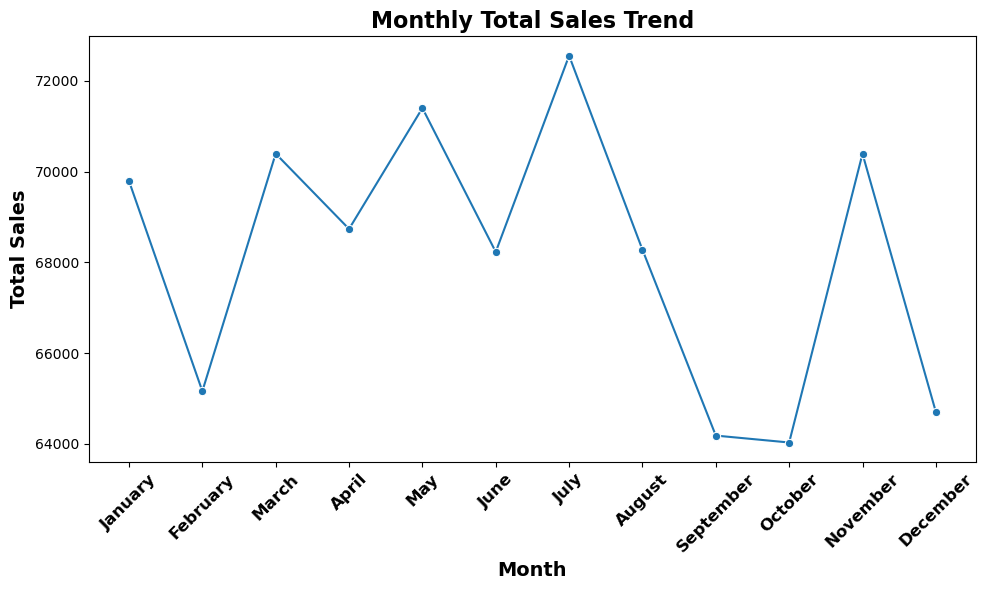

In [57]:
plt.figure(figsize=(10,6))

# Step 1: Create a line plot of total sales per month
sns. lineplot(
    data=month_totalsales_sorted_order,  # Data source
    x="Month",                            # X-axis: month names
    y="Total sales",                      # Y-axis: total sales
    marker="o"                            # Add markers at each month for clarity
)

# Step 2: Rotate x-axis labels for readability
plt.xticks(rotation=45, fontsize=12, fontweight="bold")

# Step 3: Add labels for axes
plt.xlabel("Month", fontsize=14, fontweight="bold")
plt.ylabel("Total Sales", fontsize=14, fontweight="bold")

# Step 4: Add a professional title
plt.title("Monthly Total Sales Trend", fontsize=16, fontweight="bold")

# Save figure
fig.savefig("pizza_ Monthly trend.png", dpi=300)


# Step 5: Display the chart
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()

### Monthly trend analysis
The monthly sales data for the year demonstrates a generally stable performance with predictable seasonal variations. The highest monthly sales were recorded in May (₦71,402.75) and July (₦72,557.90), driving Q2 to be the strongest quarter with total sales of ₦208,369.75, while the lowest sales occurred in September (₦64,180.05) and October (₦64,027.60), contributing to Q4 being the weakest quarter at ₦199,124.10. Q1 and Q3 performed moderately, with total sales of ₦205,350.00 and ₦205,993.10 respectively, reflecting consistent business activity across the first three quarters. The monthly trend indicates slight fluctuations but no extreme volatility, suggesting that the business maintains steady demand throughout the year. These insights suggest that inventory and marketing strategies should be prioritized around peak months such as May and July, while targeted promotions during slower months in Q4 could help smooth seasonal dips. Overall, the data provides a reliable basis for strategic planning, forecasting, and performance evaluation, ensuring resources are allocated efficiently to capitalize on high-demand periods and mitigate slower sales cycles.